# 1. 芯片初始化操作

In [4]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
import numpy as np
import random

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np

import time
from util import plot_v_cond,plot_cond

# 2. 读器件

## 2.1 常规读操作

In [116]:
# 初始化
chip=CHIP(PS(host="192.168.1.11", port = 7, delay=0.3, debug=0),init=True)

chip.IsRERAM512 = True
chip.setting.IsRERAM512 = True
chip.set_device_cfg(deviceType=0)

chip.set_op_mode(read=True,from_row=True)                                   # 设置为读模式, 并且是从行读
chip.set_dac_read_V(0.11,tg=5)                                                 # 设置读电压, 会根据device的自动配置对应的DAC通道
chip.adc.set_gain_resistor(big_resistance=33e3,small_resistance=200)        # 设置TIA增益使用的电阻大小
chip.set_tia_gain(1)                                                        # 设置TIA的增益
print(chip.get_setting_info())
chip.set_chip_sel(9)
chip.set_pulse_width(10e-3)
chip.adc.set_gap(adc_cs_gap=200,adc_first_gap=100,adc_last_gap=10)
chip.clk_manager.set_cyc(100, 100)

chip.set_cim_reset()

Connected to 192.168.1.11:7
local ip: 192.168.1.15 local port: 50456
操作模式: read	器件: ReRAM	读电压: 0.11v	从行\列给电压: 行	TIA增益: 1


In [117]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(3)
chip.clk_manager.set_cyc(1e2, 1e2)
voltage = chip.read(row_index=[1],col_index=[1],row_value=None,col_value=None,check_tia=True)
print(voltage)
chip.voltage_to_cond(voltage=voltage)

[-0.00015259]


array([-7.62962737])

0.0
-3.814813684499649
3.814813684499671
-1.9074068422498245
0.0
5.7222205267494735
1.9074068422498571
0.0
5.722220526749485
5.7222205267494735
3.814813684499627
7.629627368999298
0.0
-5.7222205267494735
-3.814813684499671
1.9074068422498245
-38.14813684499649
-3.814813684499649
-5.722220526749485
3.814813684499649
26.703695791497523
0.0
-97.27774895474107
1.9074068422498245
24.79628894924771
-5.7222205267494735
9.537034211249113
-1.9074068422498245
-47.6851710562456
-5.7222205267494735
-5.722220526749485
0.0
-49.59257789849542
0.0
-59.12961210974453
-3.814813684499649
13.351847895748653
5.7222205267494735
-53.407391582995125
-5.7222205267494735
-22.88888210699785
0.0
22.88888210699794
-1.9074068422498245
-72.48146000549336
7.629627368999298
-3.814813684499627
0.0
-41.96295052949607
-1.9074068422498245
-7.629627368999342
-1.9074068422498245
26.703695791497562
-1.9074068422498245
-43.87035737174584
7.629627368999298
7.629627368999254
3.814813684499649
13.351847895748826
3.81481368449964

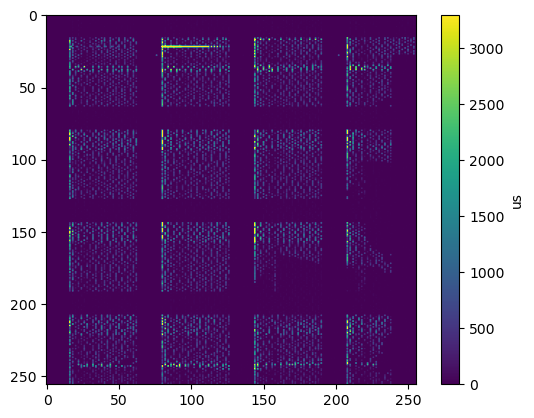

-3.814813684499627
0.0
-1.9074068422498136
1.9074068422498245
0.0
1.9074068422498245
3.814813684499671
-3.814813684499649
3.814813684499671
5.7222205267494735
0.0
1.9074068422498245
-3.814813684499627
-5.7222205267494735
7.629627368999298
5.7222205267494735
3.814813684499627
-9.537034211249123
20.98147526474808
-1.9074068422498245
-41.96295052949612
-3.814813684499649
-5.722220526749485
7.629627368999298
-49.59257789849542
-13.351847895748772
-19.074068422498264
-9.537034211249123
-9.537034211249113
5.7222205267494735
-62.9444257942442
3.814813684499649
-36.24073000274676
-11.444441053498947
-72.48146000549336
-1.9074068422498245
-36.24073000274668
0.0
-34.33332316049682
-7.629627368999298
-53.407391582995125
7.629627368999298
26.703695791497562
5.7222205267494735
-32.42591631824705
-5.7222205267494735
-83.92590105899224
-11.444441053498947
-36.24073000274668
-17.16666158024842
-74.38886684774313
1.9074068422498245
-30.51850947599719
1.9074068422498245
26.70369579149748
-7.629627368999

In [ ]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(3)
chip.clk_manager.set_cyc(1e2, 1e2)

conds = np.zeros((19, 256,256))

for chip_num in range(1, 18):
    chip.set_chip_sel(chip_num)
    cnt = 256
    # conds = np.zeros((cnt, cnt))

    for i in range(0, cnt):
        for j in range(0, cnt):
            chip.set_cim_reset()

            # chip.set_latch([i],row=True,value=None)
            # chip.set_latch([j],row=False,value=None)

            # print(chip.setting.TIA_index_map(j,col=True))

            # chip.generate_read_pulse()
            # tia_num = chip.setting.TIA_index_map(j)

            # voltage = chip.get_tia_out([tia_num])
            chip.set_dac_read_V(0)
            voltage_base = chip.read(row_index=[i],col_index=[j],row_value=None,col_value=None,check_tia=True)
            chip.set_dac_read_V(0.1)
            voltage = chip.read(row_index=[i],col_index=[j],row_value=None,col_value=None,check_tia=True)

            conds[chip_num][i][j] = chip.voltage_to_cond(voltage=voltage[0]-voltage_base[0])
            print(conds[chip_num][i][j])
    plot_cond(conds[chip_num], 0, 3300)
    np.save(f'conds2/conds{chip_num}.npy', conds)
# plot_cond(conds, 2300, 3300)
# plot_cond(conds, 0, 3300)


In [2]:
import numpy as np
data = np.load(f'conds2/conds1.npy')

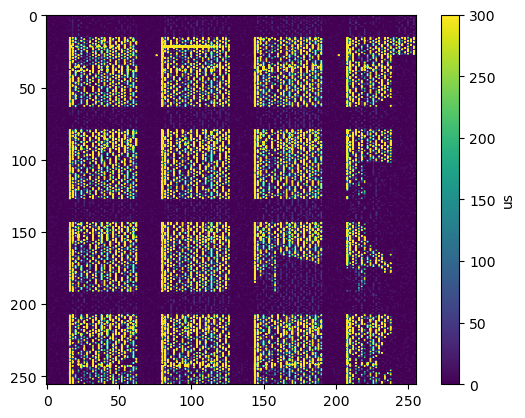

In [5]:
plot_cond(data[1], 0, 300)

In [3]:
conds_all = np.zeros((18, 256, 256))
for chip_num in range(18):
    conds_chip = np.load(f'conds/conds{chip_num}.npy')
    conds_all[chip_num] = conds_chip[chip_num]
    # print(f'loaded chip {chip_num}')
    # print(conds_chip[chip_num].shape)


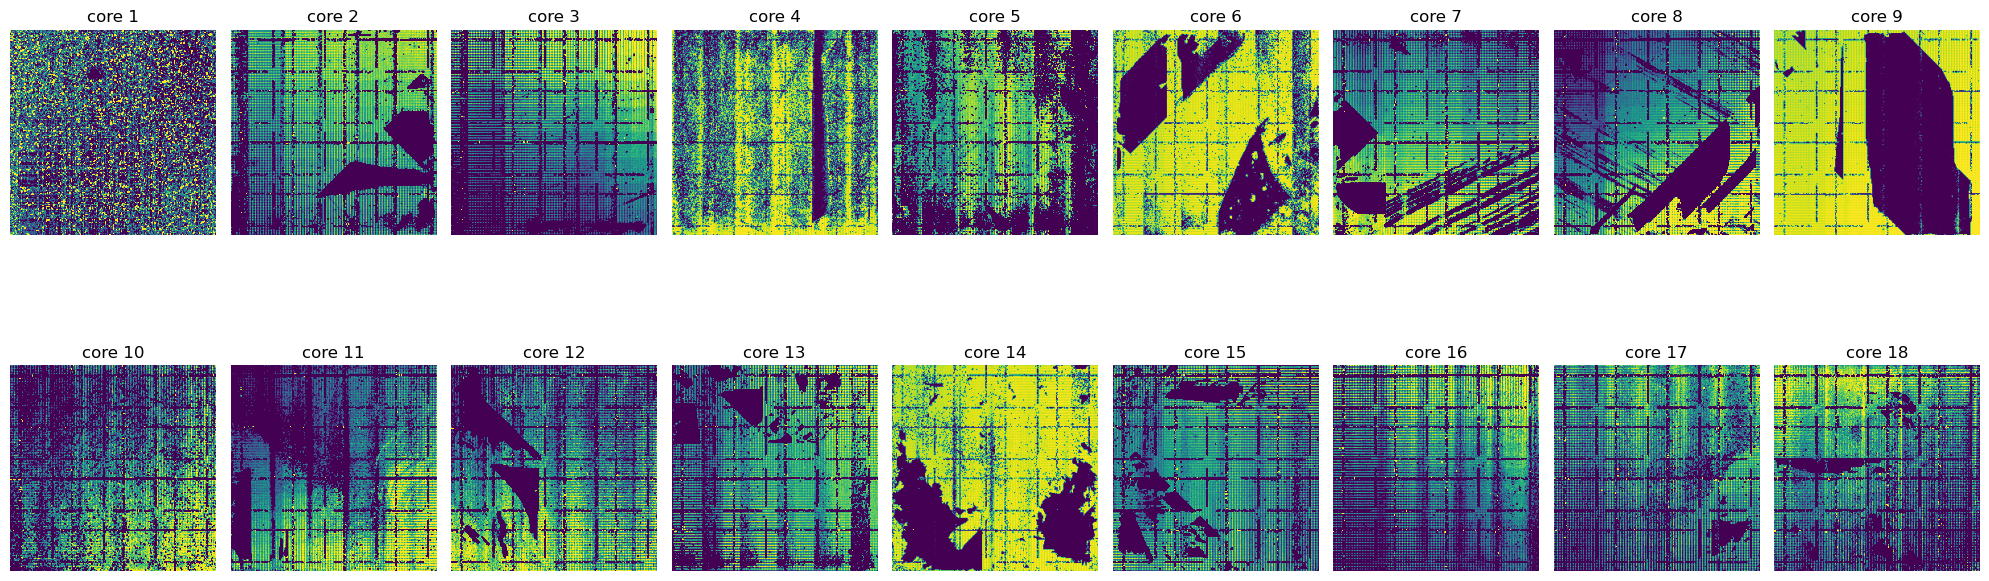

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# 创建一个 2 行 9 列的子图布局
fig, axes = plt.subplots(nrows=2, ncols=9, figsize=(20, 8))  # 调整 figsize 以适应显示需求

# 遍历每个子图
for i, ax in enumerate(axes.flatten()):
    plot_data = conds_all[i]
    
    vmin = np.percentile(plot_data, 30)
    vmax = np.percentile(plot_data, 90)
    
    # 绘制热图
    im = ax.imshow(plot_data, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f"core {i+1}")
    ax.axis('off')  # 关闭坐标轴

# 添加一个统一的 colorbar
# fig.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.02, pad=0.04)

# 调整子图之间的间距
plt.tight_layout()
plt.show()

需要读65536个点


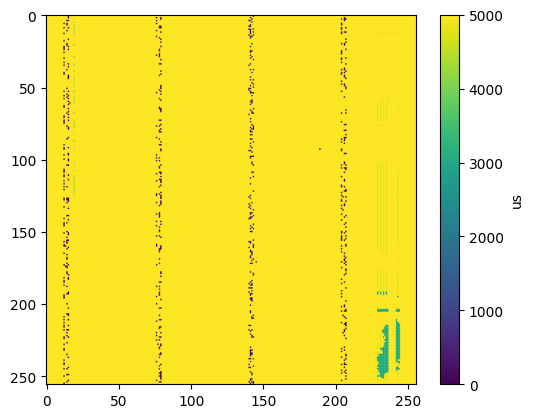

In [15]:
chip.clk_manager.set_cyc(20, 1e2)
cond = chip.read_point2(crossbar=np.ones((256,256)),read_voltage=0.1,tg=5,gain=3,from_row=True,out_type=1)
plot_cond(cond,vmax=5000)

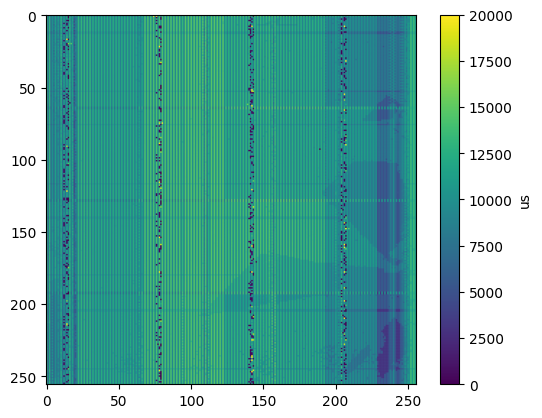

In [17]:
plot_cond(cond,vmax=20000)

In [ ]:
# plot_cond(conds, vmax=3500, vmin=3000)

import matplotlib.pyplot as plt
import numpy as np

# 创建 2 行 9 列的子图布局
fig, axes = plt.subplots(nrows=2, ncols=9, figsize=(20, 6))  # figsize 调整整个画布的大小

# 循环遍历每个子图
for i in range(2):  # 行
    for j in range(9):  # 列
        ax = axes[i, j]  # 获取当前子图的轴对象
        # 在每个子图中绘制一些示例数据
        x = np.linspace(0, 10, 100)
        y = np.sin(x + i * j)  # 示例数据，根据行列索引调整
        ax.imshow(conds,vmax=3500, vmin=3000)
        ax.set_title(f'Subplot {i+1},{j+1}')  # 设置子图标题

# 调整子图之间的间距
plt.tight_layout()

# 显示图形
plt.show()

In [ ]:
# 检查映射
chip.setting.TIA_index_map(0)

In [ ]:
# chip.dac.set_voltage(5,dac_num=1,dac_channel=0)            # TG
# chip.dac.set_voltage(1,dac_num=1,dac_channel=3)             # ROW_Va
chip.set_cim_reset()
chip.set_tia_gain(1) 

chip.set_chip_sel(5)

voltage = chip.read(row_index=[197],col_index=[61],row_value=None,col_value=None,check_tia=True)

print(f"电压:{voltage}v")
cond = chip.voltage_to_cond(voltage=voltage)
print(f"电导:{cond}us")
# resistance = chip.voltage_to_resistance(voltage=voltage)2020202020202020202020202020202020202020
# print(f"电阻:{voltage}kΩ")

In [ ]:
chip.clk_manager.set_cyc(1e2, 1e2)
chip.set_chip_sel(17)
chip.set_cim_reset()
row_num, col_num = 10, 15
voltage_list = []
cond_list = []
for i in range(30):
    # print(f"{i}")
    voltage = chip.read(row_index=[row_num],col_index=[col_num],row_value=None,col_value=None,check_tia=True)
    voltage_list.append(voltage)

    # print(f"电压:{voltage}v")
    cond = chip.voltage_to_cond(voltage=voltage)
    cond_list.append(cond)
    # print(f"电导:{cond}us")
    # resistance = chip.voltage_to_resistance(voltage=voltage)2020202020202020202020202020202020202020
    # print(f"电阻:{voltage}kΩ")

x = range(len(cond_list))
plt.plot(x, cond_list, marker='o', linestyle='-', color='b', label='Voltage')
plt.ylim(min(min(cond_list) - 100, 0), max(cond_list) + 100)
plt.title('Voltage Over Time')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(3)
chip.set_chip_sel(17)
chip.clk_manager.set_cyc(1e2, 1e4)
chip.set_cim_reset()

select_point_nums = 9
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx in range(select_point_nums):
    row_num, col_num = random.randint(0, 256), random.randint(0, 256)
    voltage_list = []
    cond_list = []

    
    chip.set_cim_reset()

    chip.set_latch([row_num],row=True,value=None)
    chip.set_latch([col_num],row=False,value=None)

    for i in range(30):

        # print(chip.setting.TIA_index_map(row_num,col=True))

        chip.generate_read_pulse()
        tia_num = chip.setting.TIA_index_map(col_num)

        # voltage = chip.get_tia_out([k for k in range(16)])
        # max_voltage = np.max(voltage)

        voltage = chip.get_tia_out([tia_num])
        cond_cur = chip.voltage_to_cond(voltage=voltage[0], read_voltage=0.1)
        # print(cond_cur)
        
        voltage_list.append(voltage)
        # print(f"电压:{voltage}v")
        cond = chip.voltage_to_cond(voltage=voltage, read_voltage=0.1)
        cond_list.append(cond)
        # print(f"电导:{cond}us")
        # resistance = chip.voltage_to_resistance(voltage=voltage)2020202020202020202020202020202020202020
        # print(f"电阻:{voltage}kΩ")

    ax = axes[idx // 3, idx % 3]
    x = range(len(cond_list))
    ax.plot(x, cond_list, marker='o', linestyle='-', color='b', label='Voltage')
    ax.set_ylim(min(min(cond_list) - 100, 0), max(cond_list) + 100)
    ax.set_title(f'row: {row_num} col: {col_num}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Voltage (V)')
    ax.grid(True)
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(3)
chip.set_chip_sel(2)
chip.clk_manager.set_cyc(1e2, 1e2)

times = 10
row_start, col_start = 140, 100
cnt = 10
conds = np.zeros((times, cnt, cnt))

for k in range(0, times):
    for i in range(row_start, row_start + cnt):
        for j in range(col_start, col_start + cnt):
            chip.set_cim_reset()

            chip.set_latch([i],row=True,value=None)
            chip.set_latch([j],row=False,value=None)

            # print(chip.setting.TIA_index_map(j,col=True))

            chip.generate_read_pulse()
            tia_num = chip.setting.TIA_index_map_512k(j)

            # voltage = chip.get_tia_out([k for k in range(16)])
            # max_voltage = np.max(voltage)

            voltage = chip.get_tia_out([tia_num])
            conds[k][i - row_start][j - col_start] = chip.voltage_to_cond(voltage=voltage[0])
            # print(conds[k][i][j])
    # plot_cond(conds[k], 0, 2000)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        data = conds[i * 3 + j]

        cmap = plt.cm.viridis
        norm = Normalize(vmin=0, vmax=1400)
        
        im = ax.imshow(data, cmap=cmap, norm=norm)
        cbar = plt.colorbar(im, ax=ax)  # 绑定色条到子图
        cbar.set_label("us")
        ax.set_title(f"Plot {i*3 + j + 1}")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# 假设 data 是 10×256×256 维度的电导测量数据
data = conds

# 计算每个点的均值、标准差、最大-最小范围
mean_values = np.mean(data, axis=0)  # 计算均值
std_values = np.std(data, axis=0)    # 计算标准差
min_values = np.min(data, axis=0)    # 计算最小值
max_values = np.max(data, axis=0)    # 计算最大值
range_values = max_values - min_values  # 计算范围

range_threshold = max_values * 0.1  # 允许的最大范围

# 选出稳定点 (标准差小于阈值 且 最大-最小值范围小于阈值)
stable_mask = (range_values < range_threshold)

# 统计稳定点个数
num_stable_points = np.sum(stable_mask)
print(f"稳定点个数: {num_stable_points} / {cnt*cnt}")

# 获取稳定点的位置
stable_indices = np.argwhere(stable_mask)  # 返回稳定点的索引

## 2.2 自定义配置latch读操作

In [ ]:
# 写操作
condition_reset=np.zeros((256,256))
condition_reset[:,10]=1
chip.write_point2(crossbar=condition_reset,write_voltage=5,tg=3,pulse_width=1e-3,set_device=True)

In [ ]:
chip.set_op_mode(read=True,from_row=True)

chip.set_tia_gain(1)
chip.set_chip_sel(2)
# 先需要reset所有的latch
chip.set_cim_reset()

# 选任意行配ltach
# chip.set_latch([100],row=True,value=None)
# 选任意行bank配32bit值
chip.set_bank([i for i in range(8)],row=True,value=0xFFFF_FFFF)

# # 配置列bank
chip.set_latch([0],row=False,value=None)
# chip.set_bank([i for i in range(8)],row=False,value=0xFFFF_FFFF)
print(chip.setting.TIA_index_map(100,col=True))

plt.figure()
for i in range(4):
    chip.set_dac_read_V(i*0.02+0.02)
    chip.generate_read_pulse()
    voltage = chip.get_tia_out([k for k in range(16)])
    

    plt.plot(voltage,marker='o', linestyle='-', linewidth=2,label=f"voltage{i}")
    plt.ylabel("voltage(v)")
    plt.xlabel("TIA")
    plt.legend()

    time.sleep(1)

    # plt.subplot(1,2,2)
    # plt.plot(cond,marker='o', linestyle='-', linewidth=2,label="cond")
    # plt.ylabel("cond(us)")
    # plt.xlabel("TIA")

plt.legend()
plt.show()
# 产生读脉冲, 并读出tia值
# chip.generate_read_pulse()
# voltage = chip.get_tia_out([k for k in range(16)])1

# plot_v_cond(v= voltage,cond= chip.voltage_to_cond(voltage))

In [ ]:
from collections import defaultdict

chip.set_op_mode(read=True,from_row=True)

chip.set_tia_gain(1)
chip.set_chip_sel(2)

map_old_new = defaultdict(list)

for col_num in range(256):

    chip.set_cim_reset()

    chip.set_bank([i for i in range(8)],row=True,value=0xFFFF_FFFF)

    chip.set_latch([col_num],row=False,value=None)

    chip.set_dac_read_V(i*0.02+0.02)
    chip.generate_read_pulse()
    voltage = chip.get_tia_out([k for k in range(16)])
    tia_new_map = np.argmax(voltage)
    
    tia_old_map = chip.setting.TIA_index_map(col_num, col=True)
    # print(f"col: {col_num} old map: {tia_old_map} new map: {tia_new_map}")

    map_old_new[int(tia_old_map)].append(int(tia_new_map))

for k, v in map_old_new.items():
    print(f"{k}: {v}")


In [ ]:

chip.setting.TIA_index_map_512k(255)

In [ ]:
chip.send_cmd(cmd=[CMD(CIM_RESET,command_data=CmdData(0))],mode=1)
chip.send_cmd(cmd=[CMD(CIM_RESET,command_data=CmdData(1))],mode=1)
chip.send_cmd(cmd=[CMD(CIM_RESET,command_data=CmdData(0))],mode=1)

In [ ]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(1)
chip.set_chip_sel(17)
chip.clk_manager.set_cyc(1e2, 1e2)


In [ ]:
def read(self,row_index:list,col_index:list, 
            row_value = None, col_value = None, 
            check_tia=True) -> np.ndarray:
    """
        Args:
            row_index: 要配置的任意行索引
            col_index: 要配置的任意列索引
            row_value: 如果row_value不为None,将会把这些行涉及的bank全配置成32bit的row_value值
            col_value: 如果col_value不为None,将会把这些列涉及的bank全配置成32bit的col_value值
            check_tia: 表示是否需要处理一路TIA只能映射一列的问题

        Returns:
            np.ndarray为电压(v)
    """
    assert self.op_mode == "read","未设置为读模式。"
    assert self.read_voltage is not None,"未设置读电压。"

    if not self.from_row:
        row_index, col_index = col_index, row_index
    # ----------------------------------------------行数据映射
    row_data = self.setting.get_bank_index_tia(row_index,self.from_row)
    col_data = self.setting.get_bank_index_tia(col_index,self.from_row)                                                 # 映射得到i,num,bank, index, tia
    # ----------------------------------------------映射16路tia
    col_batch = self.setting.tia_split(col_data,check_tia = check_tia)
    # ----------------------------------------------循环去读
    res = []
    for i in col_batch:
        # ------------------------------------------reset然后配置行
        self.set_cim_reset()
        self.set_latch([j[1] for j in row_data],row=self.from_row,value=row_value)
        self.set_latch([j[1] for j in i],row=not self.from_row,value=col_value)
        # ------------------------------------------给读脉冲
        self.generate_read_pulse() 
        # ------------------------------------------读出结果
        if not check_tia:
            res.append(self.adc.get_out([i for i in range(self.setting.chip_tia_num)]))
        else:
            res.append(self.adc.get_out([j[4] for j in i]))
    if not check_tia:
        result_v = [res[i] for i in range(len(col_batch))]
    else:
        # ----------------------------------------------将结果映射回原来的顺序
        result_v = [0]*len(col_index)
        for i,v1 in enumerate(col_batch):
            # 第i个批次读, v2为(pos, row_num/col_num, bank, index, tia_num)
            for j,v2 in enumerate(v1):
                result_v[v2[0]]=res[i][j]
    if not self.from_row:
        return np.array(result_v).T
    else:
        return np.array(result_v)

In [ ]:
chip.set_chip_sel(18)
chip.clk_manager.set_cyc(10, 100)
need=np.ones((256,256))
# need[:,180:220]=1
voltage_base_point_row = chip.read_point2(crossbar=need,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage_point_row = chip.read_point2(crossbar=need,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond_sub_base_row = chip.voltage_to_cond(voltage=voltage_point_row-voltage_base_point_row)
plot_cond(cond_sub_base_row,title="cond_point_sub_base_row",vmax=200)

In [ ]:
cond_sub_base_row = chip.voltage_to_cond(voltage=voltage_point_row-voltage_base_point_row)
plot_cond(cond_sub_base_row,title="cond_point_sub_base_row",vmin=-50,vmax=50)

In [ ]:
plot_cond(cond_sub_base_row,title="cond_point_sub_base_row",vmax=100)

In [ ]:
plot_cond(cond_sub_base_row,title="cond_point_sub_base_row")

In [ ]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(1)
chip.set_chip_sel(18)
chip.clk_manager.set_cyc(1e2, 1e2)

cnt = 100
conds = np.zeros((cnt, 40))
# chip.set_cim_reset()
chip.send_cmd(cmd=[CMD(COL_CTRL,command_data=CmdData(0))],mode=1)
for i in range(0, cnt):
    for j in range(180, 220):
        
        chip.send_cmd(cmd=[CMD(COL_CTRL,command_data=CmdData(0))],mode=1)

        # chip.set_latch([i],row=True,value=None)
        # chip.set_latch([j],row=False,value=None)

        # print(chip.setting.TIA_index_map(j,col=True))

        chip.generate_read_pulse()
        tia_num = chip.setting.TIA_index_map(j)

        voltage = chip.get_tia_out([tia_num])
        print(voltage)
        

        # voltage = read(chip,row_index=[i],col_index=[j],row_value=None,col_value=None,check_tia=True)

        conds[i][j-180] = chip.voltage_to_cond(voltage=voltage[0])
        print(conds[i][j-180])

# plot_cond(conds, 2300, 3300)
plot_cond(conds, 0, 3300)
        

In [ ]:
plot_cond(conds, 0, 200)

In [ ]:
# conds[245, 180]
chip.send_cmd(cmd=[CMD(CIM_RESET,command_data=CmdData(0))],mode=1)
chip.send_cmd(cmd=[CMD(CIM_RESET,command_data=CmdData(1))],mode=1)
chip.send_cmd(cmd=[CMD(CIM_RESET,command_data=CmdData(0))],mode=1)

In [ ]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(1)
chip.set_chip_sel(19)
# 先需要reset所有的latch
chip.set_cim_reset()
chip.send_cmd(cmd=[CMD(COL_CTRL,command_data=CmdData(0))],mode=1)
# 选任意行配ltach
chip.set_latch([0],row=True,value=None)
# 选任意行bank配32bit值
# chip.set_bank([i for i in range(8)],row=True,value=0xFFFF_FFFF)

# # 配置列bank
# chip.set_latch([[2,4,1,3]],row=False,value=None)
chip.set_bank([i for i in range(8)],row=False,value=0xFFFF_FFFF)

# 产生读脉冲, 并读出tia值
chip.generate_read_pulse()
voltage = chip.get_tia_out([k for k in range(16)])

plot_v_cond(v= voltage,cond= chip.voltage_to_cond(voltage))

# 3. 写器件

## 3.1 常规写操作

In [ ]:
chip.set_op_mode(read=False,from_row=True)                                  # 设置为写模式, 并且是从行写
chip.set_dac_write_V(0.1)                                                   # 设置为写模式, 并且是从行写
chip.set_pulse_width(0.1)                                                   # 设置写脉冲宽度
print(chip.get_setting_info())

In [ ]:
chip.write_one(row_index=0,col_index=0)

## 3.2 自定义配置行列写操作

In [ ]:
chip.set_op_mode(read=False,from_row=True)                                  # 设置为写模式, 并且是从行写
chip.set_dac_write_V(0.1)                                                   # 设置为写模式, 并且是从行写
chip.set_pulse_width(0.1)                                                   # 设置写脉冲宽度
print(chip.get_setting_info())

In [ ]:
# 先需要reset所有的latch
chip.set_cim_reset()

# 配置行bank
chip.set_latch([2,4,253,255],row=True,value=None)
chip.set_bank([i for i in range(8)],row=True,value=0xFFFF_FFFF)

# 配置列bank
chip.set_latch([2,4,1,3],row=False,value=None)
chip.set_bank([i for i in range(8)],row=False,value=0xFFFF_FFFF)

# 产生写配置
chip.generate_write_pulse()

# 3. 测试

## 3.1 测试选通对不对

In [ ]:
chip.set_op_mode(read=True,from_row=True)                                   # 设置为读模式, 并且是从行读
chip.set_dac_read_V(0.1,tg=5)                                               # 设置读电压, 会根据device的自动配置对应的DAC通道
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)        # 设置TIA增益使用的电阻大小
chip.set_tia_gain(1)                                                        # 设置TIA的增益
print(chip.get_setting_info())

In [ ]:
# 0或1 ：串行读写32个寄存器的使能
chip.send_cmd(cmd = [CMD(CIM_EN,command_data=CmdData(1))],mode=1)

In [ ]:
def is_correct_value(voltage,threshold,tia_num):
    for key,value in enumerate(voltage):
        if value>=threshold:
            if key in tia_num:
                pass
            else:
                print(f"这路TIA不应该有值:tia={key},value={value},threshold={threshold}")
                return False
        else:
            if key not in tia_num:
                pass
            else:
                print(f"这路TIA应该有值:tia={key},value={value},threshold={threshold}")
                return False
    return True

In [ ]:
col_bank = 2

chip.send_cmd(cmd = [CMD(SER_PARA_SEL,command_data=CmdData(1))],mode=1)
chip.set_cim_reset()
chip.set_bank([0],row=True,value=0xFFFF_FFFF)
chip.set_bank([col_bank],row=False,value=0x0000_0003)
col_index = chip.setting.bank_to_num([col_bank])

chip.generate_read_pulse()
voltage = chip.get_tia_out([k for k in range(16)])

print(f"第{0}, {1}位设置为1",voltage)
plot_v_cond(voltage,chip.voltage_to_cond(voltage))

for j in range(32):
    chip.send_cmd(cmd = [CMD(SER_PARA_SEL,command_data=CmdData(0))],mode=1)
    chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_reg_clk))],mode=1)          # cfg_reg_clk
    chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_latch_clk))],mode=1)        # cfg_latch_clk

    chip.generate_read_pulse()
    voltage = chip.get_tia_out([k for k in range(16)])
    print(f"第{j}次挤出一位")
    # plot_v_cond(voltage,chip.voltage_to_cond(voltage))
    if j == 31:
        print(is_correct_value(voltage,0.1,tia_num=[]))
    else:
        col1,col2= col_index[min(31,j+1)],col_index[min(31,j+2)]
        tia = [chip.setting.TIA_index_map(col1),chip.setting.TIA_index_map(col2)]
        print(is_correct_value(voltage,0.1,tia_num=tia))